In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import casadi as ca

Question 4

Nous pouvons considéré un seul véhicule car ils ont tous la même charge maximale et le même $\beta$.

On a $\forall i \in [0; N-1], Q_{i+1} = Q_i + \Delta t\beta P_i$

Ainsi : $\forall i \in [0; N-1], \beta P_i = (SOC_{i+1}-SOC_i)Q_{barre}/\Delta t$ qui va constituer notre problème des moindres carrés. 

Question 5 :

On veut résoudre Ax = b avec A qui est la matrice des puissances


La valeur de beta trouvé pour les données brutes est : 0.002982908229641423


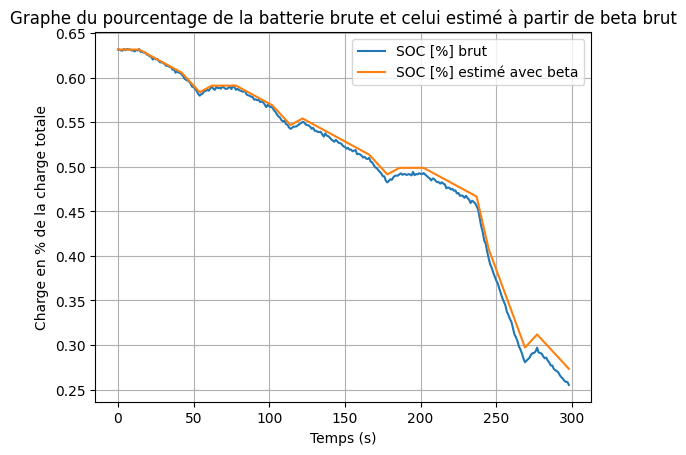

In [130]:
#Question 5
U_sec = 230
Q_barre = 50*3600

data = pd.read_csv("data_battery.csv")
N = len(data)

time = np.array(data["Time [s]"])
list_A = np.array(1000*U_sec*data["I [kA]"]) 
A = list_A[:N-1]
A = A.reshape((N-1, 1))

SOC = np.array(data["SOC [%]"])
b = (SOC[1:]-SOC[:N-1])*Q_barre/(time[1:]-time[:N-1])
b = b.reshape((N-1,1))

#Pour le problème des moindres carrés, on peut prendre la solution explicite : Beta = (A^T*A)^{-1}*(A^T*b) ou utiliser la fonction np.linalg.lstsq pour résoudre Ax = b
sol = np.linalg.lstsq(A, b) #sol[0] = beta ; sol[1] = somme des résidus ; sol[2] = rang de la matrice A ; sol[3] = valeur singulière de A
beta = sol[0][0][0]

print("La valeur de beta trouvé pour les données brutes est :", beta)

#Estimation de la charge de la batterie à partir de la valeur Beta

#initialisation
SOC_estime = np.zeros(N)
SOC_estime[0] = data["SOC [%]"].iloc[0]

#Récurrence
for i in range(1, N):
    SOC_estime[i]=SOC_estime[i-1] + (time[i]-time[i-1])*beta*list_A[i]/Q_barre

#Affichage du graphe de la batterie
data["SOC [%] brut"] = data["SOC [%]"]
data['SOC [%] lissé'] = data["SOC [%]"].rolling(window = 5, on = data.index).mean()
data['SOC [%] estimé avec beta'] = SOC_estime
data[['SOC [%] brut', 'SOC [%] estimé avec beta']].plot(title = "Graphe du pourcentage de la batterie brute et celui estimé à partir de beta brut")
plt.xlabel("Temps (s)")
plt.ylabel("Charge en % de la charge totale")
plt.grid()
plt.show()

La valeur de beta trouvé pour les données lissées est : 0.002618604830899051


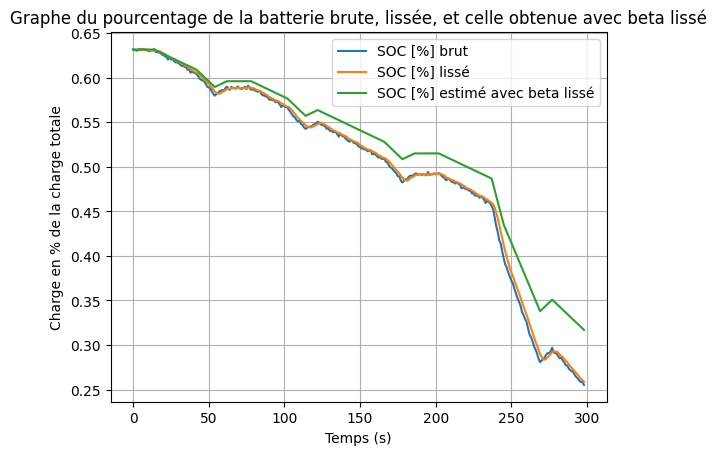

In [131]:
#Question 5
U_sec = 230
Q_barre = 50*3600
window = 5

data = pd.read_csv("data_battery.csv")
data['SOC [%] lissé'] = data["SOC [%]"].rolling(window = window).mean()
N = len(data)

time = np.array(data["Time [s]"])
list_A = np.array(1000*U_sec*data["I [kA]"]) 
A = list_A[:N-window]
A = A.reshape((N-window, 1))

SOC_lisse = np.array(data["SOC [%] lissé"])
b_lisse = (SOC_lisse[window:]-SOC_lisse[window-1:N-1])*Q_barre/(time[window:]-time[window-1:N-1])
b_lisse = b_lisse.reshape((N-window,1))

#Pour le problème des moindres carrés, on peut prendre la solution explicite : Beta = (A^T*A)^{-1}*(A^T*b) ou utiliser la fonction np.linalg.lstsq pour résoudre Ax = b
sol_lisse = np.linalg.lstsq(A, b_lisse) #sol[0] = beta ; sol[1] = somme des résidus ; sol[2] = rang de la matrice A ; sol[3] = valeur singulière de A
beta_lisse = sol_lisse[0][0][0]

print("La valeur de beta trouvé pour les données lissées est :", beta_lisse)

#Estimation de la charge de la batterie à partir de la valeur Beta

#initialisation
SOC_estime_lisse = np.zeros(N)
SOC_estime_lisse[0] = data["SOC [%]"].iloc[0]

#Récurrence
for i in range(1, N):
    SOC_estime_lisse[i]=SOC_estime_lisse[i-1] + (time[i]-time[i-1])*beta_lisse*list_A[i]/Q_barre

#Affichage du graphe de la batterie
data["SOC [%] brut"] = data["SOC [%]"]
data['SOC [%] estimé avec beta lissé'] = SOC_estime_lisse
data[['SOC [%] brut', 'SOC [%] lissé', 'SOC [%] estimé avec beta lissé']].plot(title = "Graphe du pourcentage de la batterie brute, lissée, et celle obtenue avec beta lissé")
plt.xlabel("Temps (s)")
plt.ylabel("Charge en % de la charge totale")
plt.grid()
plt.show()


On remarque que l'on est dans une situation de décharge de la batterie. Cela ne pose pas de problème pour le calcul de beta. 

In [81]:
#Les données sont les suivantes : 

ccr = 1 #tarif heure creuse
cpl = 3/2 #tarif heure plein
t0 = 17 #on initialise à 17h
dt = 900 #0,25h en seconde
minuit = 8*4
six_h = minuit + 6*4
douze_h = minuit + 12*4
quat_h = minuit + 14*4
Q_barre = 50*3600 #A.s
P_barre =2.5*1000 #W
n_vehicule = 2
T = 24*4
H_arr = np.array([4,6]) #nombre de dt à partir de 17h
H_dep = np.array([64,68]) #nombre de dt à partir de 17h
SOC_ini = np.array([0.3,0.5]) #état de charge à l'arrivée

In [134]:
#liste des coûts en fonction de l'heure de la journée
prix = []
for i in range(T) :
    if i < minuit or (i> six_h and i< douze_h) or i> quat_h :
        prix.append(cpl)
    else : 
        prix.append(ccr)

prix = ca.SX([prix, prix])

In [135]:
P = ca.SX.sym('P', n_vehicule, T)
Q = ca.SX.sym('Q', n_vehicule, T)

x = ca.vertcat(
    ca.reshape(P, n_vehicule*T, 1),
    ca.reshape(Q,n_vehicule*T, 1)
)

#objective 
cost = dt * ca.sum(prix * P)

In [ ]:
n_vehicule = 2
T = 24*4 #nombre de temps j
beta = beta_lisse

lbx = []
ubx = []

#Bounds on P
lbx += [0]*(n_vehicule*T)
ubx += [P_barre]*(n_vehicule*T)

#Bounds on Q (SOC entre 0 et 1)
lbx += [0]*(n_vehicule*T)
ubx += [1]*(n_vehicule*T)

g = []
lbg = []
ubg = []

#Contrainte ceq1 :
for j in range(n_vehicule):
    for k in range(H_arr[j]):
        g.append(P[j,k])
        lbg.append(0.0)
        ubg.append(0.0)
    for k in range(T-H_dep[j]):
        g.append(P[j, T-k-1])
        lbg.append(0.0)
        ubg.append(0.0)

#Contrainte ceq2 : Qj,i+1 - Qj,i -beta*delta_t*Pj,i = 0
for j in range(n_vehicule):
    for i in range(T-1):
        g.append(Q[j, i+1] - Q[j, i] - (beta * dt) * P[j, i])
        lbg.append(0.0)
        ubg.append(0.0)

#Contrainte ceq3 : 
for j in range(n_vehicule):
    g.append(Q[j,H_arr[j]]-SOC_ini[j])
    lbg.append(0.0)
    ubg.append(0.0)

#Contrainte ceq4 :
for j in range(n_vehicule):
    g.append(Q[j,H_dep[j]]-1) #Il faut qu'ils soit chargé à 100% à la fin
    lbg.append(0.0)
    ubg.append(0.0)

#Contrainte cin2 :
for i in range(T):
    g.append(ca.sum(P[:,i]))
    lbg.append(0.0)
    ubg.append(P_barre)

In [139]:
# Convertir les contraintes en vecteur
g_vec = ca.vertcat(*g)

nlp = {'x':x, 'f': cost, 'g': g_vec}
solver = ca.nlpsol('s', 'ipopt', nlp)

sol = solver(
    x0 = np.ones(2*n_vehicule*T),
    lbx = np.array(lbx),
    ubx = np.array(ubx),
    lbg = np.array(lbg),
    ubg = np.array(ubg),
)

P_sol = sol['x'][:n_vehicule*T]
Q_sol = sol['x'][n_vehicule*T:]

P_sol = ca.reshape(P_sol, n_vehicule, T)
Q_sol =  ca.reshape(Q_sol, n_vehicule, T)

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      644
Number of nonzeros in inequality constraint Jacobian.:      192
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      384
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      384
                     variables with only upper bounds:        0
Total number of equality constraints.................:      264
Total number of inequality constraints...............:       96
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:       96
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  2.5400000e+02 1.00e+00 2.00e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

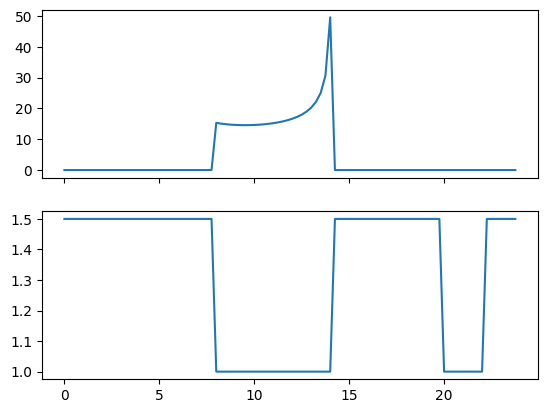

In [142]:
prix = []
for i in range(T) :
    if i < minuit or (i> six_h and i< douze_h) or i> quat_h :
        prix.append(cpl)
    else : 
        prix.append(ccr)

P_tot = np.array(P_sol[0,:]).reshape(T)+np.array(P_sol[1,:]).reshape(T)
temps = np.arange(T)/4
Prix = np.array(prix)

fig, ax = plt.subplots(2, sharex=True)
ax[0].plot(temps, P_tot)
ax[1].plot(temps, Prix)
#ax.set_xlabel('temps [h]')
#ax.grid()

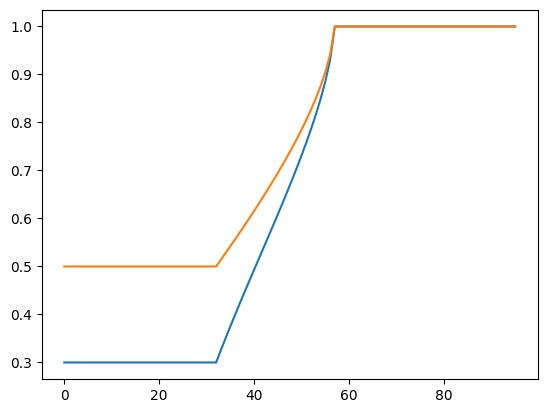

In [122]:
Q_1 = np.array(Q_sol[0,:]).reshape(T)
Q_2 = np.array(Q_sol[1,:]).reshape(T)
temps = np.arange(T)
plt.plot(temps, Q_1)
plt.plot(temps, Q_2)

#### *Question 8 :*
Le problème ici est que l'on ne sait pas à l'avance à quelle heure veulent repartir les clients. Il faut donc commencer à charger dès le début.
De même, il y a peu de chance que toutes les batteries aient la même charge finale et l'optimiseur ne peut pas avoir accès à cette information. 
